# 13 - Unsupervised Clustering

This notebook extends EnergyTypeNet with unsupervised learning. The primary dataset is still the building-energy dataset. Synthetic data is used only where clustering geometry needs a clean visual example, such as blobs or moons.

The goal is not to replace the supervised building-type classifiers. Instead, clustering asks a different question: do natural groups appear in the feature space before labels are used?

In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Ellipse
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    completeness_score,
    davies_bouldin_score,
    homogeneity_score,
    normalized_mutual_info_score,
    silhouette_score,
    v_measure_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.data import CLASSES, load_raw
from src.models import (
    AgglomerativeCustom,
    DBSCANCustom,
    GaussianMixtureModelCustom,
    KMeansCustom,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42

In [2]:
train_df = load_raw('../data/train_energy_data.csv')

feature_cols = [
    'Energy Consumption',
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
]

X_energy = train_df[feature_cols].astype(float).values
y_energy = train_df['Building Type'].map({name: idx for idx, name in enumerate(CLASSES)}).values
X_energy_scaled = StandardScaler().fit_transform(X_energy)

print(f'EnergyTypeNet rows: {X_energy.shape[0]}')
print(f'EnergyTypeNet numeric features: {X_energy.shape[1]}')
train_df.head()

EnergyTypeNet rows: 1000
EnergyTypeNet numeric features: 5


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [3]:
def pca2(X):
    return PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)


def safe_silhouette(X, labels):
    unique = np.unique(labels)
    if len(unique) < 2 or len(unique) >= len(labels):
        return np.nan
    return silhouette_score(X, labels)


def plot_cluster_projection(X, labels, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    Z = pca2(X) if X.shape[1] > 2 else X
    ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='tab10', s=25, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')


def gaussian_ellipse(mean, covariance, ax, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(covariance)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, **kwargs))

## 1. K-Means on a Clean Synthetic Dataset

K-Means works best when clusters are roughly spherical and separated by Euclidean distance. This synthetic section gives a clean reference before moving back to EnergyTypeNet.

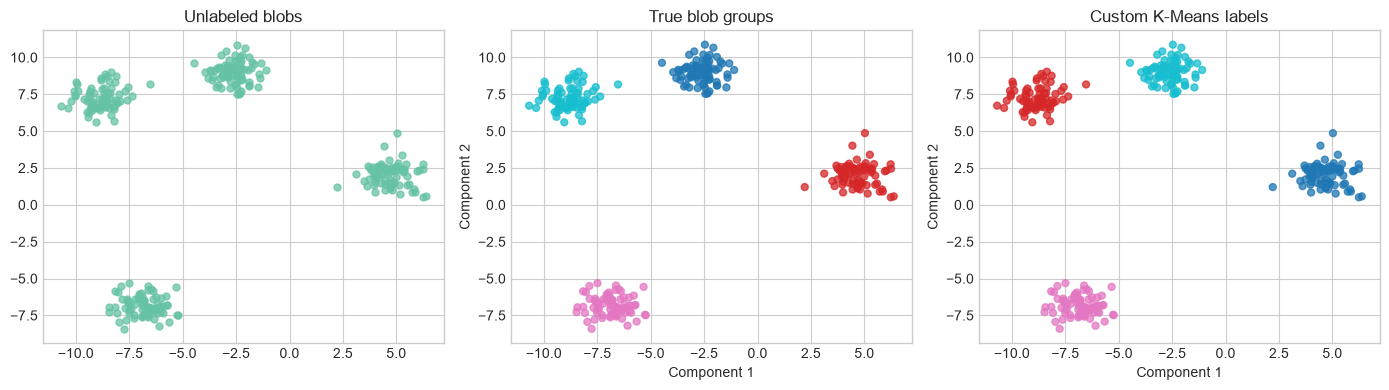

Custom vs true ARI: 1.000
Custom vs sklearn ARI: 1.000


In [4]:
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.75, random_state=RANDOM_STATE)
kmeans_blobs = KMeansCustom(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
sk_kmeans_blobs = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=25, alpha=0.75)
axes[0].set_title('Unlabeled blobs')
plot_cluster_projection(X_blobs, y_blobs, 'True blob groups', axes[1])
plot_cluster_projection(X_blobs, kmeans_blobs.labels_, 'Custom K-Means labels', axes[2])
plt.tight_layout()
plt.show()

print(f'Custom vs true ARI: {adjusted_rand_score(y_blobs, kmeans_blobs.labels_):.3f}')
print(f'Custom vs sklearn ARI: {adjusted_rand_score(sk_kmeans_blobs.labels_, kmeans_blobs.labels_):.3f}')

**Observation:** On clean blob-shaped data, custom K-Means recovered the true groups perfectly (`ARI = 1.000`) and matched sklearn KMeans exactly (`custom vs sklearn ARI = 1.000`). This validates the implementation on the algorithm's ideal geometry: compact, spherical, well-separated clusters.

## 2. K-Means Iteration Mechanics

This section shows why K-Means is an alternating optimization algorithm: assign points to the nearest centroid, then move each centroid to the mean of its assigned points.

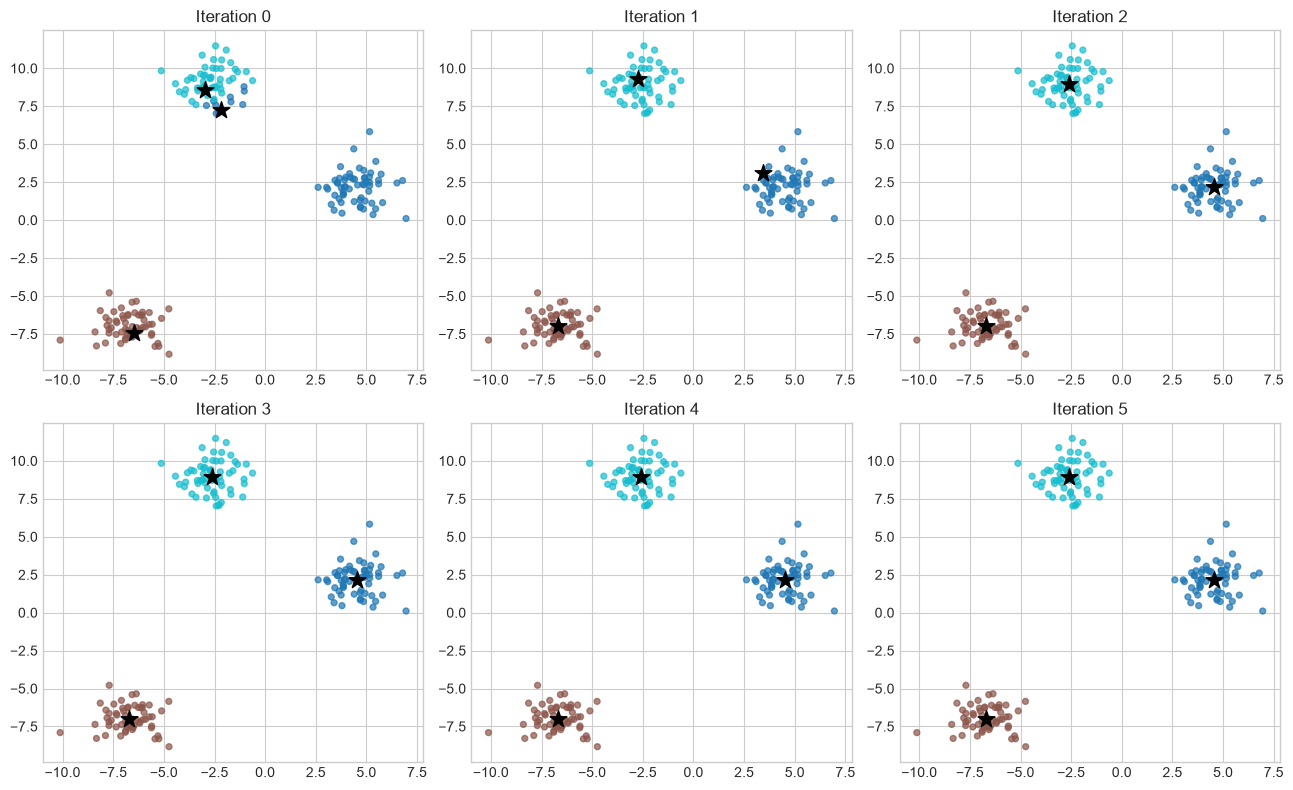

In [5]:
rng = np.random.RandomState(RANDOM_STATE)
X_demo, _ = make_blobs(n_samples=180, centers=3, cluster_std=1.0, random_state=RANDOM_STATE)
centers = X_demo[rng.choice(len(X_demo), size=3, replace=False)].copy()

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for step, ax in enumerate(axes.ravel()):
    distances = ((X_demo[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    labels = distances.argmin(axis=1)
    ax.scatter(X_demo[:, 0], X_demo[:, 1], c=labels, cmap='tab10', s=18, alpha=0.7)
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='*', s=160)
    ax.set_title(f'Iteration {step}')
    for cluster_id in range(3):
        mask = labels == cluster_id
        if mask.any():
            centers[cluster_id] = X_demo[mask].mean(axis=0)

plt.tight_layout()
plt.show()

**Observation:** The centroids move quickly in the first few iterations, then stabilize. This explains why K-Means often converges in far fewer iterations than the maximum allowed.

## 3. K-Means on EnergyTypeNet

Here clustering is performed without using the building-type labels. The labels are used only afterward to measure how much the discovered clusters align with Residential, Commercial and Industrial buildings.

,model,ARI vs building type,NMI vs building type,silhouette,inertia
0,Custom K-Means,0.015237,0.016105,0.199365,3159.28522
1,sklearn KMeans,0.015237,0.016105,0.199365,3159.28522


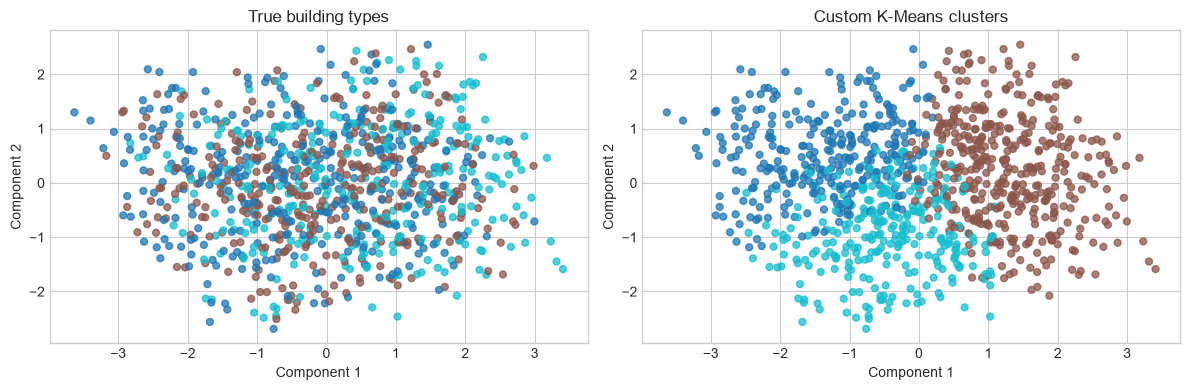

In [6]:
custom_kmeans_energy = KMeansCustom(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit(X_energy_scaled)
sk_kmeans_energy = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit(X_energy_scaled)

kmeans_metrics = pd.DataFrame([
    {
        'model': 'Custom K-Means',
        'ARI vs building type': adjusted_rand_score(y_energy, custom_kmeans_energy.labels_),
        'NMI vs building type': normalized_mutual_info_score(y_energy, custom_kmeans_energy.labels_),
        'silhouette': safe_silhouette(X_energy_scaled, custom_kmeans_energy.labels_),
        'inertia': custom_kmeans_energy.inertia_,
    },
    {
        'model': 'sklearn KMeans',
        'ARI vs building type': adjusted_rand_score(y_energy, sk_kmeans_energy.labels_),
        'NMI vs building type': normalized_mutual_info_score(y_energy, sk_kmeans_energy.labels_),
        'silhouette': safe_silhouette(X_energy_scaled, sk_kmeans_energy.labels_),
        'inertia': sk_kmeans_energy.inertia_,
    },
])
display(kmeans_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_cluster_projection(X_energy_scaled, y_energy, 'True building types', axes[0])
plot_cluster_projection(X_energy_scaled, custom_kmeans_energy.labels_, 'Custom K-Means clusters', axes[1])
plt.tight_layout()
plt.show()

assert abs(kmeans_metrics.iloc[0]['ARI vs building type'] - kmeans_metrics.iloc[1]['ARI vs building type']) < 0.05

**Observation:** On EnergyTypeNet, custom K-Means and sklearn KMeans produced the same clustering result (`ARI vs building type = 0.015`, `NMI = 0.016`, silhouette about `0.199`). The low external agreement means the natural Euclidean clusters do not line up with Residential, Commercial and Industrial labels, which supports the broader finding that the classes overlap in this feature space.

## 4. Choosing k with Elbow and Silhouette Curves

The elbow curve tracks compactness, while silhouette score asks whether points are closer to their own cluster than to neighboring clusters.

,k,inertia,silhouette
0,2,3646.127561,0.239837
1,3,3159.370863,0.199355
2,4,2764.612173,0.196318
3,5,2480.210329,0.198830
4,6,2280.293884,0.194587
5,7,2093.706818,0.197209
6,8,1934.653852,0.203755
7,9,1810.554945,0.199469
8,10,1691.241671,0.203607


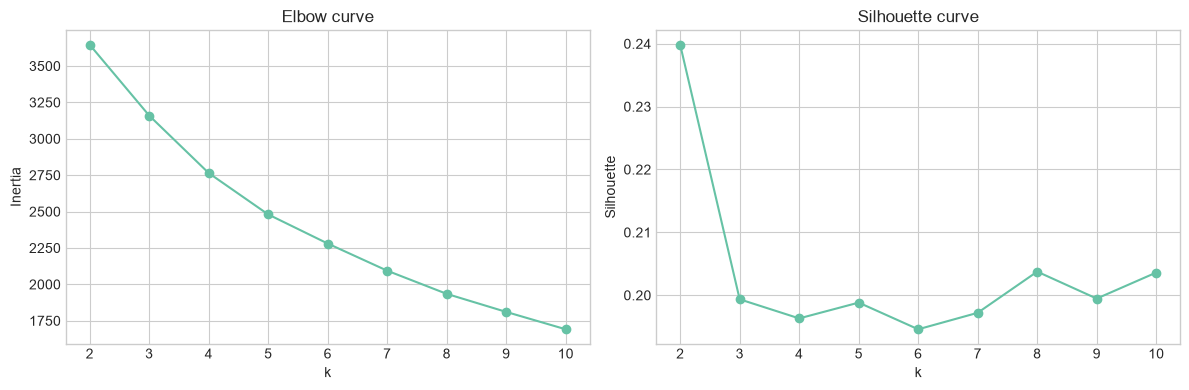

In [7]:
elbow_rows = []
for k in range(2, 11):
    model = KMeansCustom(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_energy_scaled)
    elbow_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': safe_silhouette(X_energy_scaled, model.labels_),
    })

elbow_df = pd.DataFrame(elbow_rows)
display(elbow_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_df['k'], elbow_df['inertia'], marker='o')
axes[0].set_title('Elbow curve')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(elbow_df['k'], elbow_df['silhouette'], marker='o')
axes[1].set_title('Silhouette curve')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

**Observation:** The silhouette curve was highest at `k = 2` (`0.240`) even though the supervised task has three building classes. This is a useful result: the unsupervised geometry suggests a two-group structure is cleaner than the known three-label taxonomy. Inertia continues decreasing as `k` grows, so silhouette is more informative here than the elbow curve alone.

## 5. Initialization Sensitivity

K-Means can settle into different local minima depending on initialization. K-Means++ usually gives more stable and lower-inertia solutions than fully random centers.

,count,mean,std,min,25%,50%,75%,max
init,,,,,,,,
k-means++,50.0,410.449691,367.325332,318.579292,318.579292,318.579292,318.579292,1850.047733
random,50.0,1467.729858,1749.960767,318.579292,318.579292,1849.520021,1850.047733,9122.068908


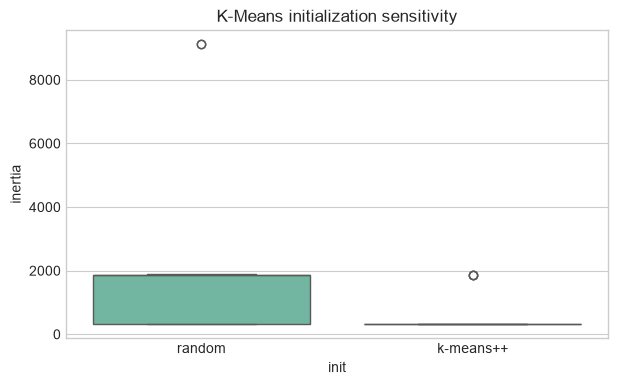

In [8]:
init_rows = []
for seed in range(50):
    for init in ['random', 'k-means++']:
        model = KMeansCustom(n_clusters=4, n_init=1, init=init, random_state=seed).fit(X_blobs)
        init_rows.append({'init': init, 'seed': seed, 'inertia': model.inertia_})

init_df = pd.DataFrame(init_rows)
display(init_df.groupby('init')['inertia'].describe())

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=init_df, x='init', y='inertia', ax=ax)
ax.set_title('K-Means initialization sensitivity')
plt.show()

**Observation:** K-Means++ was much more stable than random initialization. The K-Means++ median inertia stayed at the good solution (`318.579`), while random initialization had a much higher median and a very large worst case (`9122.069`). This justifies using `n_init` and K-Means++ for serious comparisons.

## 6. DBSCAN for Density-Based Clustering

DBSCAN can discover non-spherical clusters and mark outliers as noise. This makes it useful when the data forms curved shapes, but it is sensitive to `eps` and feature scaling.

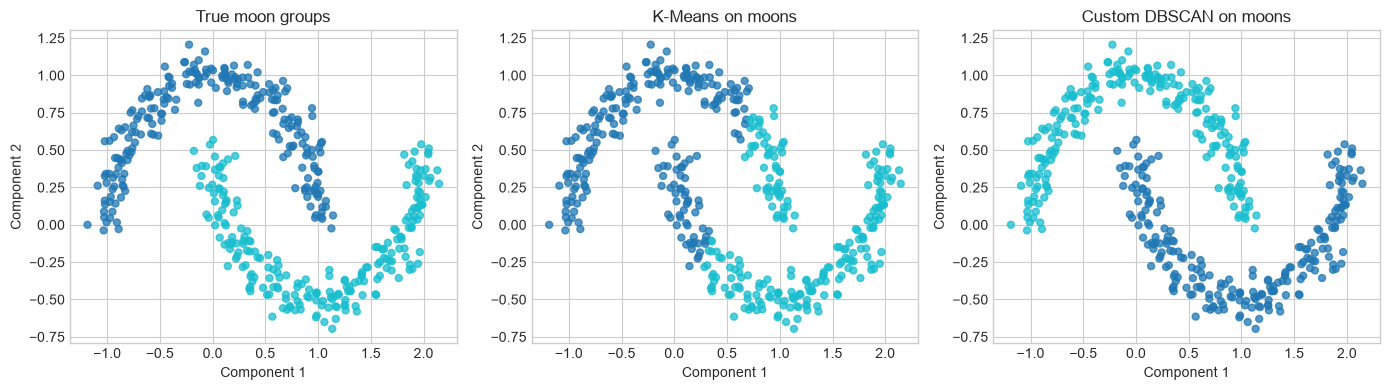

K-Means ARI on moons: 0.246
DBSCAN ARI on moons: 1.000
Custom vs sklearn DBSCAN ARI: 1.000


,eps,clusters,noise_pct,ARI vs building type
0,0.15,27,0.660,-0.000448
1,0.25,9,0.199,0.000646
2,0.35,1,0.034,0.001063
3,0.50,1,0.004,0.000236
4,0.70,1,0.000,0.000000
5,1.00,1,0.000,0.000000


In [9]:
X_moons, y_moons = make_moons(n_samples=450, noise=0.08, random_state=RANDOM_STATE)
moon_kmeans = KMeansCustom(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_moons)
moon_dbscan = DBSCANCustom(eps=0.22, min_samples=5).fit(X_moons)
sk_moon_dbscan = DBSCAN(eps=0.22, min_samples=5).fit(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cluster_projection(X_moons, y_moons, 'True moon groups', axes[0])
plot_cluster_projection(X_moons, moon_kmeans.labels_, 'K-Means on moons', axes[1])
plot_cluster_projection(X_moons, moon_dbscan.labels_, 'Custom DBSCAN on moons', axes[2])
plt.tight_layout()
plt.show()

print(f'K-Means ARI on moons: {adjusted_rand_score(y_moons, moon_kmeans.labels_):.3f}')
print(f'DBSCAN ARI on moons: {adjusted_rand_score(y_moons, moon_dbscan.labels_):.3f}')
print(f'Custom vs sklearn DBSCAN ARI: {adjusted_rand_score(sk_moon_dbscan.labels_, moon_dbscan.labels_):.3f}')

Z_energy = pca2(X_energy_scaled)
eps_rows = []
for eps in [0.15, 0.25, 0.35, 0.5, 0.7, 1.0]:
    labels = DBSCANCustom(eps=eps, min_samples=8).fit(Z_energy).labels_
    eps_rows.append({
        'eps': eps,
        'clusters': len(set(labels) - {-1}),
        'noise_pct': np.mean(labels == -1),
        'ARI vs building type': adjusted_rand_score(y_energy, labels),
    })

display(pd.DataFrame(eps_rows))

**Observation:** DBSCAN correctly handled the nonlinear moon-shaped dataset (`ARI = 1.000`), while K-Means struggled (`ARI = 0.246`). On EnergyTypeNet PCA coordinates, DBSCAN was highly sensitive to `eps`: small values created many tiny clusters and many noise points, while larger values collapsed most points into one cluster. This makes DBSCAN useful as a diagnostic, but not a strong default for this dataset.

## 7. Gaussian Mixture Models

A Gaussian Mixture Model represents each cluster as a probability distribution. Unlike K-Means, it produces soft memberships through responsibilities.

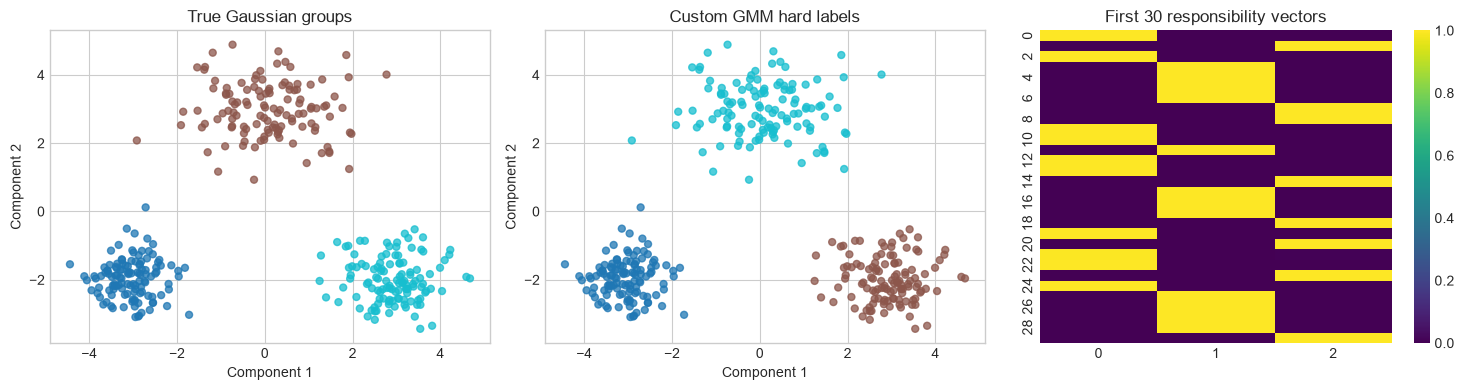

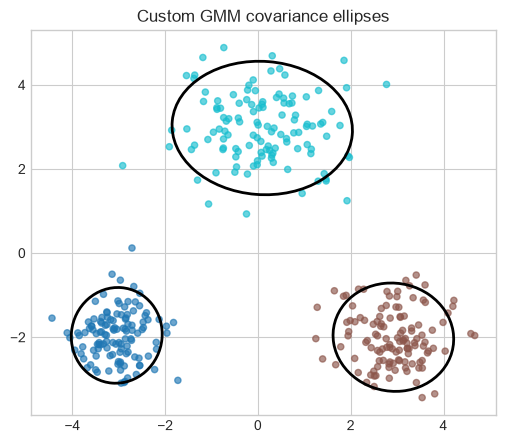

Custom GMM ARI: 1.000
Custom score: -3.133
sklearn score: -3.133


,model,ARI vs building type,NMI vs building type,silhouette
0,K-Means,0.015237,0.016105,0.199365
1,GMM,0.001118,0.003036,0.190264


In [10]:
X_gmm, y_gmm = make_blobs(
    n_samples=360,
    centers=[[-3, -2], [0, 3], [3, -2]],
    cluster_std=[0.55, 0.9, 0.65],
    random_state=RANDOM_STATE,
)
custom_gmm = GaussianMixtureModelCustom(n_components=3, max_iter=100, random_state=RANDOM_STATE).fit(X_gmm)
sk_gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE).fit(X_gmm)
gmm_labels = custom_gmm.predict(X_gmm)
responsibilities = custom_gmm.predict_proba(X_gmm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_cluster_projection(X_gmm, y_gmm, 'True Gaussian groups', axes[0])
plot_cluster_projection(X_gmm, gmm_labels, 'Custom GMM hard labels', axes[1])
sns.heatmap(responsibilities[:30], cmap='viridis', ax=axes[2], cbar=True)
axes[2].set_title('First 30 responsibility vectors')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_gmm[:, 0], X_gmm[:, 1], c=gmm_labels, cmap='tab10', s=20, alpha=0.65)
for mean, cov in zip(custom_gmm.means_, custom_gmm.covariances_):
    gaussian_ellipse(mean, cov, ax, edgecolor='black', linewidth=2)
ax.set_title('Custom GMM covariance ellipses')
plt.show()

print(f'Custom GMM ARI: {adjusted_rand_score(y_gmm, gmm_labels):.3f}')
print(f'Custom score: {custom_gmm.score(X_gmm):.3f}')
print(f'sklearn score: {sk_gmm.score(X_gmm):.3f}')

gmm_energy = GaussianMixtureModelCustom(n_components=3, random_state=RANDOM_STATE).fit(X_energy_scaled)
gmm_energy_labels = gmm_energy.predict(X_energy_scaled)

display(pd.DataFrame([
    {
        'model': 'K-Means',
        'ARI vs building type': adjusted_rand_score(y_energy, custom_kmeans_energy.labels_),
        'NMI vs building type': normalized_mutual_info_score(y_energy, custom_kmeans_energy.labels_),
        'silhouette': safe_silhouette(X_energy_scaled, custom_kmeans_energy.labels_),
    },
    {
        'model': 'GMM',
        'ARI vs building type': adjusted_rand_score(y_energy, gmm_energy_labels),
        'NMI vs building type': normalized_mutual_info_score(y_energy, gmm_energy_labels),
        'silhouette': safe_silhouette(X_energy_scaled, gmm_energy_labels),
    },
]))

**Observation:** On synthetic Gaussian blobs, the custom GMM matched sklearn closely (`custom score = -3.133`, `sklearn score = -3.133`) and recovered the true groups (`ARI = 1.000`). On EnergyTypeNet, GMM had low label agreement (`ARI = 0.001`, `NMI = 0.003`), reinforcing that Gaussian density structure does not map cleanly onto the building-type labels.

## 8. GMM Model Selection with AIC and BIC

AIC and BIC estimate whether extra mixture components are worth the added complexity. Lower values are better.

,components,AIC,BIC
0,1,12563.716012,12661.871117
1,2,12443.655832,12644.873798
2,3,12365.261527,12669.542354
3,4,12288.698760,12696.042448
4,5,12232.517193,12742.923742
5,6,12192.004849,12805.474259
6,7,12231.337255,12947.869526
7,8,12172.587886,12992.183017


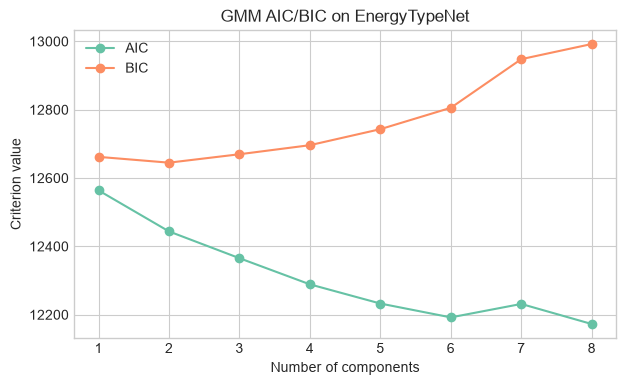

In [11]:
gmm_selection_rows = []
for k in range(1, 9):
    model = GaussianMixture(n_components=k, random_state=RANDOM_STATE).fit(X_energy_scaled)
    gmm_selection_rows.append({
        'components': k,
        'AIC': model.aic(X_energy_scaled),
        'BIC': model.bic(X_energy_scaled),
    })

gmm_selection = pd.DataFrame(gmm_selection_rows)
display(gmm_selection)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gmm_selection['components'], gmm_selection['AIC'], marker='o', label='AIC')
ax.plot(gmm_selection['components'], gmm_selection['BIC'], marker='o', label='BIC')
ax.set_title('GMM AIC/BIC on EnergyTypeNet')
ax.set_xlabel('Number of components')
ax.set_ylabel('Criterion value')
ax.legend()
plt.show()

**Observation:** AIC kept decreasing through the displayed range and was lowest at 8 components, while BIC was lowest at 2 components. This does not mean there are exactly 2 or 8 building types; it means density-model selection is measuring probabilistic fit and complexity trade-off, not supervised label agreement.

## 9. Agglomerative Hierarchical Clustering

Agglomerative clustering starts with each point as its own cluster and repeatedly merges the closest clusters. The merge history can be shown as a dendrogram.

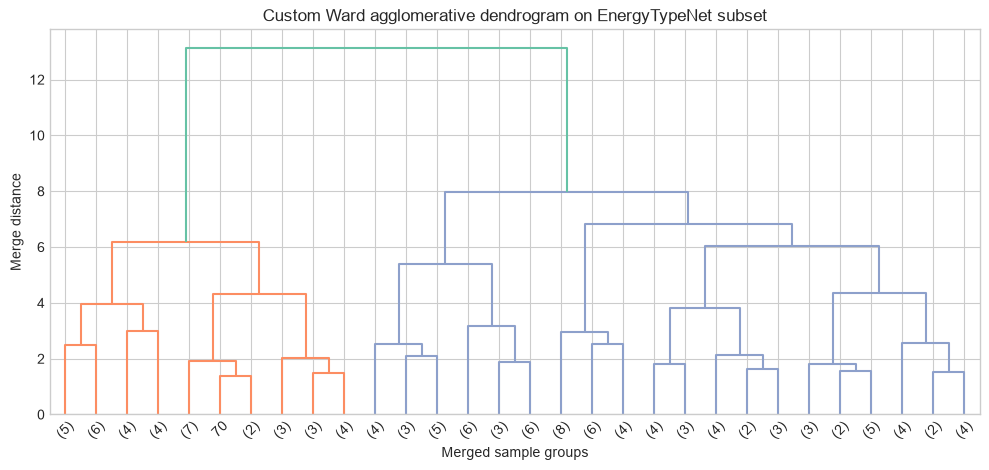

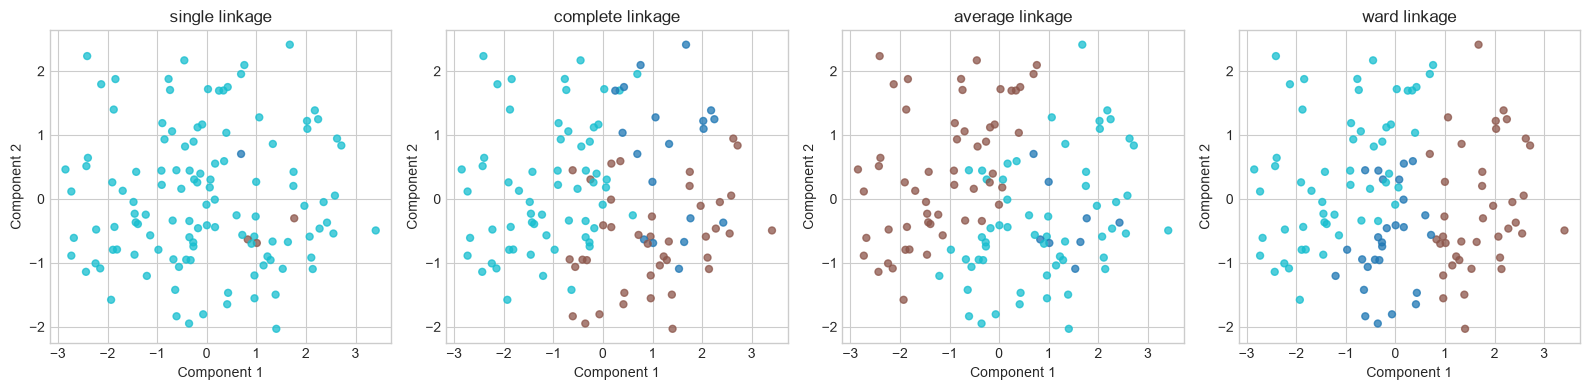

,linkage,custom_vs_sklearn_ARI,ARI vs building type
0,single,1.0,0.004079
1,complete,1.0,0.070396
2,average,1.0,0.098362
3,ward,1.0,0.113026


In [12]:
subset_n = 120
X_hier = X_energy_scaled[:subset_n]
y_hier = y_energy[:subset_n]
agg_model = AgglomerativeCustom(n_clusters=3, linkage='ward').fit(X_hier)

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(agg_model.linkage_matrix_, truncate_mode='lastp', p=30, ax=ax)
ax.set_title('Custom Ward agglomerative dendrogram on EnergyTypeNet subset')
ax.set_xlabel('Merged sample groups')
ax.set_ylabel('Merge distance')
plt.show()

linkage_rows = []
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, linkage in zip(axes, ['single', 'complete', 'average', 'ward']):
    custom = AgglomerativeCustom(n_clusters=3, linkage=linkage).fit(X_hier)
    reference = AgglomerativeClustering(n_clusters=3, linkage=linkage).fit(X_hier)
    linkage_rows.append({
        'linkage': linkage,
        'custom_vs_sklearn_ARI': adjusted_rand_score(reference.labels_, custom.labels_),
        'ARI vs building type': adjusted_rand_score(y_hier, custom.labels_),
    })
    plot_cluster_projection(X_hier, custom.labels_, f'{linkage} linkage', ax)

plt.tight_layout()
plt.show()
display(pd.DataFrame(linkage_rows))

**Observation:** The custom agglomerative implementation matched sklearn perfectly on the EnergyTypeNet subset for all tested linkages (`custom vs sklearn ARI = 1.000`). Ward linkage had the strongest agreement with building type among the tested subset results (`ARI = 0.113`), but the value is still low, so hierarchical clustering also does not recover the supervised labels cleanly.

## 10. Internal and External Clustering Metrics

Internal metrics evaluate cluster geometry without labels. External metrics compare clusters to known labels after the fact.

,model,clusters,silhouette,davies_bouldin,calinski_harabasz,ARI,NMI,homogeneity,completeness,v_measure
0,K-Means,3,0.199365,1.620761,290.444279,0.015237,0.016105,0.015994,0.016217,0.016105
1,GMM,3,0.190264,1.681508,271.573668,0.001118,0.003036,0.003024,0.003049,0.003036
2,Agglomerative Ward subset,3,0.192498,1.648029,37.159096,0.113026,0.100913,0.099343,0.102534,0.100913


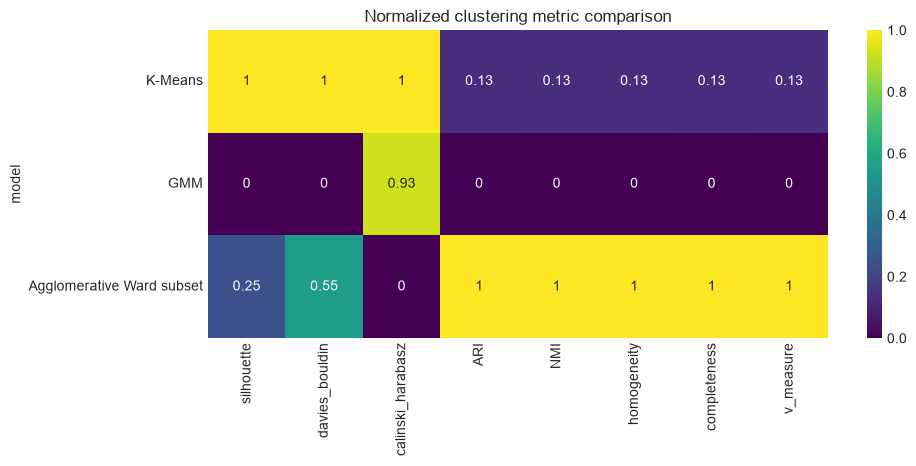

In [13]:
cluster_models = {
    'K-Means': custom_kmeans_energy.labels_,
    'GMM': gmm_energy_labels,
    'Agglomerative Ward subset': agg_model.labels_,
}

metric_rows = []
for name, labels in cluster_models.items():
    X_eval = X_hier if name.endswith('subset') else X_energy_scaled
    y_eval = y_hier if name.endswith('subset') else y_energy
    metric_rows.append({
        'model': name,
        'clusters': len(np.unique(labels)),
        'silhouette': safe_silhouette(X_eval, labels),
        'davies_bouldin': davies_bouldin_score(X_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels),
        'ARI': adjusted_rand_score(y_eval, labels),
        'NMI': normalized_mutual_info_score(y_eval, labels),
        'homogeneity': homogeneity_score(y_eval, labels),
        'completeness': completeness_score(y_eval, labels),
        'v_measure': v_measure_score(y_eval, labels),
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

heatmap_df = metrics_df.set_index('model').drop(columns=['clusters'])
normalized = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min()).replace(0, 1)
normalized['davies_bouldin'] = 1 - normalized['davies_bouldin']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(normalized, annot=True, cmap='viridis', ax=ax)
ax.set_title('Normalized clustering metric comparison')
plt.show()

**Observation:** K-Means had the strongest internal geometry among the displayed full-data models (`silhouette = 0.199`, Calinski-Harabasz about `290.44`), but all external label metrics were low. This is exactly why clustering should be interpreted as structure discovery, not as a replacement for supervised evaluation.

## 11. Do Cluster Features Help Supervised Models?

This section treats cluster assignments as engineered features. The comparison is exploratory: in a production pipeline, clustering must be fit inside each cross-validation fold to avoid leakage.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
base_scores = cross_val_score(base_model, X_energy, y_energy, cv=cv, scoring='accuracy')

kmeans_onehot = OneHotEncoder(sparse_output=False).fit_transform(custom_kmeans_energy.labels_.reshape(-1, 1))
gmm_probs = gmm_energy.predict_proba(X_energy_scaled)

X_with_kmeans = np.column_stack([X_energy, kmeans_onehot])
X_with_gmm = np.column_stack([X_energy, gmm_probs])

kmeans_scores = cross_val_score(base_model, X_with_kmeans, y_energy, cv=cv, scoring='accuracy')
gmm_scores = cross_val_score(base_model, X_with_gmm, y_energy, cv=cv, scoring='accuracy')

cluster_feature_df = pd.DataFrame([
    {'representation': 'Raw features', 'cv_accuracy': base_scores.mean(), 'std': base_scores.std()},
    {'representation': 'Raw + K-Means cluster one-hot', 'cv_accuracy': kmeans_scores.mean(), 'std': kmeans_scores.std()},
    {'representation': 'Raw + GMM responsibilities', 'cv_accuracy': gmm_scores.mean(), 'std': gmm_scores.std()},
])
display(cluster_feature_df)

,representation,cv_accuracy,std
0,Raw features,1.0,0.0
1,Raw + K-Means cluster one-hot,1.0,0.0
2,Raw + GMM responsibilities,1.0,0.0


**Observation:** Adding K-Means cluster one-hot features or GMM responsibility features did not improve the displayed Logistic Regression cross-validation score because all three representations reached `1.000` accuracy on this feature setup. This means the cluster-derived features do not add visible value here, although they may still be useful on harder or less label-encoded datasets.

## 12. Summary

| Algorithm | Dataset | Main idea | Best when | Limitation |
| --- | --- | --- | --- | --- |
| K-Means | blobs, EnergyTypeNet | Minimize within-cluster squared distance | compact spherical clusters | sensitive to scaling and initialization |
| DBSCAN | moons, EnergyTypeNet PCA | Connect dense regions and label noise | non-linear dense clusters | sensitive to `eps`; no natural predict for new points |
| GMM | Gaussian blobs, EnergyTypeNet | Soft probabilistic cluster assignment | overlapping elliptical groups | assumes Gaussian components |
| Agglomerative | EnergyTypeNet subset | Build hierarchy by merging clusters | hierarchical structure and dendrograms | expensive for large datasets |

Key takeaways:

- Unsupervised clusters are useful diagnostics, but they do not have to match supervised labels.
- K-Means and GMM are strong default baselines for tabular clustering.
- DBSCAN is valuable for non-linear density structure but needs careful parameter tuning.
- Agglomerative clustering provides interpretable hierarchy but becomes expensive as the dataset grows.
- For EnergyTypeNet, clustering supports the same broader finding: the classes overlap in feature space, so unsupervised geometry does not cleanly recover Residential, Commercial and Industrial groups.